In [14]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

import corner
import emcee

from popsummary.popresult import PopulationResult

from darksirenpop.utilities.utils import make_nice_plots, get_pdfs, hdi, sample_from_distribution
from darksirenpop.utilities.default_globals import *
from darksirenpop.hypersampler.hypersampler import *

make_nice_plots()


<!-- # Inputs when NOT fitting z_max as well -->

In [15]:
# current = 0.28935 / 2
# Ncurr = 256
# need = 0.05
# Nneed = (current / need)**2 * Ncurr
# print(Nneed)


In [16]:
nwalkers = 100
LTHRESH_STRING = '44.5'
filename_uniform = f"{GENERATED_DATA_DIR}/alt_origin_hyperparameters/sampler_uniform_priors_withcat_{LTHRESH_STRING}.h5"
filename_gauss = f"{GENERATED_DATA_DIR}/alt_origin_hyperparameters/sampler_gauss_priors_withcat_{LTHRESH_STRING}.h5"

ndim = 4
par_names = np.array(["b", "c", "d", "fagn"])
par_names_latex = np.array([r"$\gamma$", r"$1 + z_{\rm peak}$", r"$\kappa$", r"$f_{\rm agn}$"])


In [17]:
backend_uniform, pos_uniform = init_uniform_sampler(filename_uniform, nwalkers=nwalkers)
backend_gauss, pos_gauss = init_uniform_sampler(filename_gauss, nwalkers=nwalkers)


<!-- # Input when fitting z_max -->


In [18]:
def get_diagnostics(sampler, ndim=ndim, burnin=0, acceptance_fraction_low=0, acceptance_fraction_high=1, remove_extra_walker_idx=[]):

	print(sampler.acceptance_fraction)
	good_walkers = np.where((sampler.acceptance_fraction >= acceptance_fraction_low) & (sampler.acceptance_fraction <= acceptance_fraction_high))[0]
	mask = ~np.isin(good_walkers, remove_extra_walker_idx)
	good_walkers = good_walkers[mask]
		
	print(f'There are {len(good_walkers)} good walkers.')

	samples = sampler.get_chain()
	log_prob = sampler.get_log_prob()
	median_log_prob = np.median(log_prob[burnin:, good_walkers])
	print(f'lnL = {median_log_prob:.1f} +/- {np.std(log_prob[burnin:, good_walkers]):.1f}')

	fname_string = ''
	for name in par_names:
		fname_string += f'_{name}'
	# np.save(os.path.join(DATA_DIR, f'mcmc_logprob{fname_string}_{PRIOR}prior_{LABEL}'), log_prob[burnin:, good_walkers])
	# np.save(os.path.join(DATA_DIR, f'mcmc_samples{fname_string}_{PRIOR}prior_{LABEL}'), samples[burnin:, good_walkers, :])


	fig, axes = plt.subplots(ndim, figsize=(10, 10), sharex=True)
	for i in range(ndim):
		chains = samples[:, good_walkers, i]
		ax = axes[i]
		ax.plot(chains, "k", alpha=0.3)
		ax.vlines(burnin, np.min(chains), np.max(chains), linestyle='dashed', color='red')
		ax.set_xlim(0, chains.shape[0] - 1)
		ax.set_ylabel(f'{par_names_latex[i]}')
		ax.yaxis.set_label_coords(-0.1, 0.5)
	axes[-1].set_xlabel("step number")
	# plt.savefig(os.path.join(PLOT_DIR, f'walkers{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
	plt.show()


	plt.figure()
	plt.plot(log_prob[:, good_walkers])
	xmax = log_prob.shape[0] - 1
	ymin = median_log_prob * 0.95
	ymax = median_log_prob * 1.05
	plt.ylim(ymin, ymax)
	plt.xlim(0, xmax)
	plt.hlines(median_log_prob, 0, xmax, linestyle='dashed', color='black', label=f'Median after burnin')
	plt.vlines(burnin, ymin, ymax, linestyle='dashed', color='red', label='Burnin')
	plt.xlabel('step number')
	plt.ylabel('Log probability')
	plt.legend()
	# plt.savefig(os.path.join(PLOT_DIR, f'logprob{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
	plt.show()

	plt.figure()
	plt.plot(log_prob[burnin:, good_walkers])
	xmax = log_prob.shape[0] - 1
	ymin = median_log_prob * 0.95
	ymax = median_log_prob * 1.05
	# plt.ylim(ymin, ymax)
	plt.xlim(0, xmax)
	plt.hlines(median_log_prob, 0, xmax, linestyle='dashed', color='black', label=f'Median after burnin')
	plt.xlabel('step number')
	plt.ylabel('Log probability')
	plt.legend()
	# plt.savefig(os.path.join(PLOT_DIR, f'logprob{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
	plt.show()


	flat_samples = samples[burnin:, good_walkers, :].reshape(-1, ndim)
	fig = corner.corner(
		flat_samples, 
		labels=[f'{par_names_latex[i]}' for i in range(ndim)],
		show_titles=True,
		title_fmt='.2f')
	# plt.savefig(os.path.join(PLOT_DIR, f'corner{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
	plt.show()


def get_clean_samples_from_backend(filename, nwalkers, ndim, burnin, a_low, a_high, quantile=False):
	sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=emcee.backends.HDFBackend(filename))
	samples = sampler.get_chain()
	logprob = sampler.get_log_prob()

	if quantile:
		a_low = np.quantile(sampler.acceptance_fraction, a_low)
		a_high = np.quantile(sampler.acceptance_fraction, a_high)

	good_walkers = np.where((sampler.acceptance_fraction >= a_low) & (sampler.acceptance_fraction <= a_high))[0]
	good_samples = samples[burnin:, good_walkers, :].reshape(-1, ndim)
	good_logprob = logprob[burnin:, good_walkers].flatten()

	get_diagnostics(sampler, burnin=burnin, acceptance_fraction_low=a_low, acceptance_fraction_high=a_high)
	return good_samples, good_logprob, sampler.acceptance_fraction


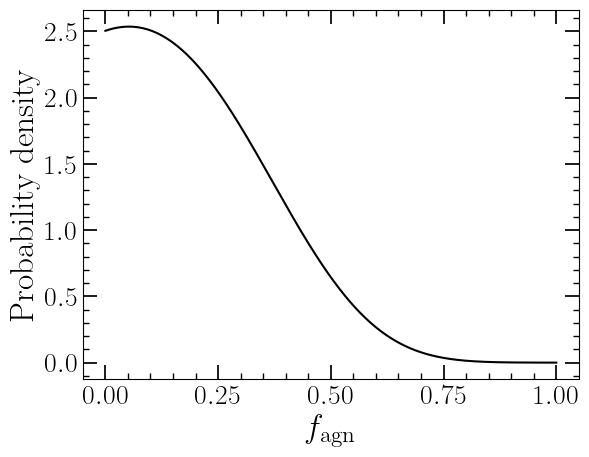

In [19]:
np.seterr(divide='ignore')

zmodel = 'madau'
thresh = f'{LTHRESH_STRING}_kulkarni'
label = '_zleq3_final_kmax5_gwtc5_luminformed_smoothcorr'
agn_json_path = f'{JSON_DIR}/real_output_{zmodel}{label}.json'

with open(agn_json_path, "r") as f:
	data = json.load(f)
	gw_evidence_dict = data[str(thresh)]

log_llh_plot = log_likelihood(np.array([3.3, 2.55, 6.1, 1]), LTHRESH_STRING, gw_evidence_dict, return_spline=True)
fixedpop_post = get_pdfs(log_llh_plot(LOG_LLH_X_AX), integrate_axis=LOG_LLH_X_AX)

plt.figure()
plt.plot(LOG_LLH_X_AX, fixedpop_post, color='black')
plt.xlabel(r'$f_{\rm agn}$')
plt.ylabel('Probability density')
plt.show()


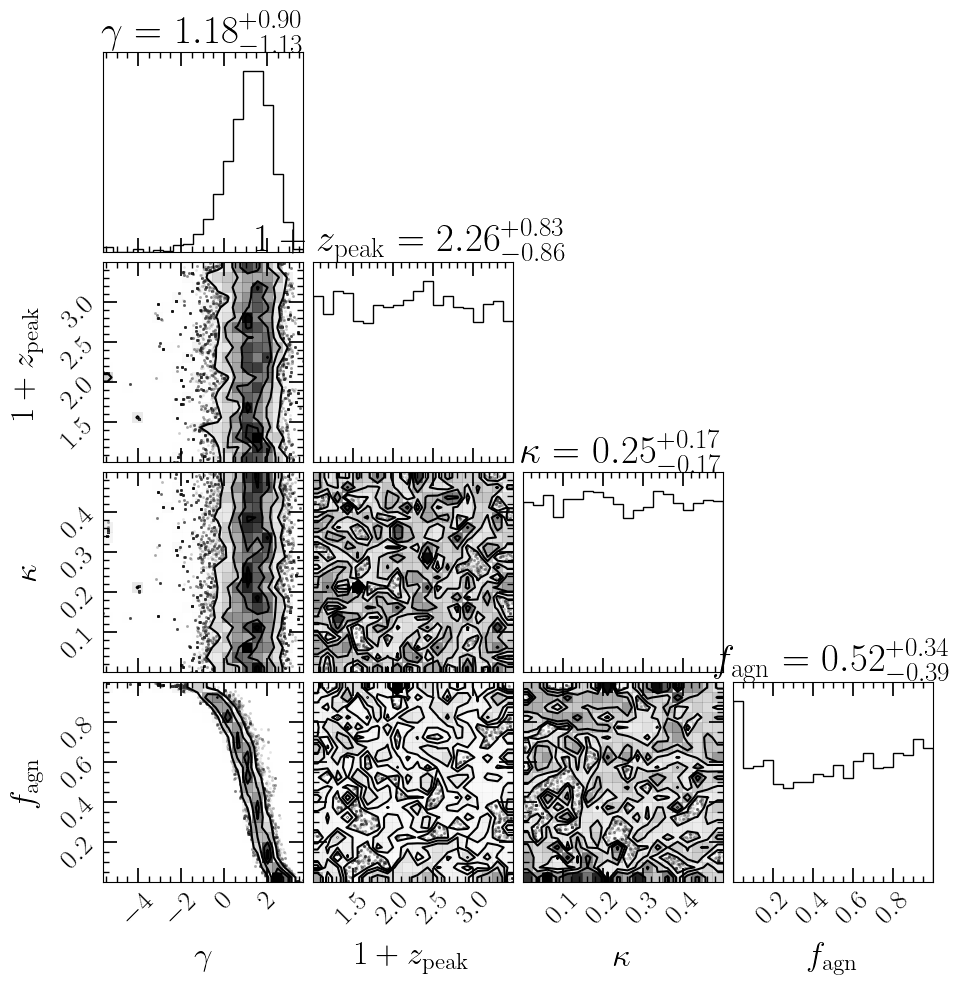

In [20]:
burnin = 200

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, backend=emcee.backends.HDFBackend(filename_uniform))
samples = sampler.get_chain()
logprob = sampler.get_log_prob()

a_low = np.quantile(sampler.acceptance_fraction, 0.05)
a_high = np.quantile(sampler.acceptance_fraction, 0.95)

good_walkers = np.where((sampler.acceptance_fraction >= a_low) & (sampler.acceptance_fraction <= a_high))[0]
# good_samples = samples[burnin:, good_walkers, :].reshape(-1, ndim)
# good_logprob = logprob[burnin:, good_walkers].flatten()

flat_samples = samples[burnin:, good_walkers, :].reshape(-1, ndim)
fig = corner.corner(
	flat_samples[flat_samples[:, 2] < 0.5], 
	labels=[f'{par_names_latex[i]}' for i in range(ndim)],
	show_titles=True,
	title_fmt='.2f')
# plt.savefig(os.path.join(PLOT_DIR, f'corner{fname_string}_{PRIOR}prior_{LABEL}.pdf'), bbox_inches='tight')
plt.show()


[0.31873479 0.32867873 0.29302867 0.28625833 0.35078811 0.31439755
 0.34190204 0.34444092 0.32412991 0.31143552 0.33555485 0.33492013
 0.31979266 0.35353856 0.33999788 0.326563   0.33745901 0.33153496
 0.30424204 0.35459642 0.33798794 0.34740294 0.35935682 0.34560457
 0.3328044  0.32645721 0.30604041 0.30953137 0.326563   0.30625198
 0.31566698 0.34327727 0.34042103 0.30762721 0.33005395 0.33164075
 0.32053316 0.35047075 0.3249762  0.3210621  0.3461335  0.31439755
 0.35110547 0.32804401 0.35576008 0.31270496 0.33407384 0.25420501
 0.326563   0.32307204 0.32444727 0.3288903  0.33015974 0.29324024
 0.34116154 0.35047075 0.31048344 0.3508939  0.34401777 0.28689305
 0.32783243 0.34306569 0.32973659 0.33809373 0.3288903  0.35544272
 0.32677457 0.33100603 0.32518777 0.31936951 0.33365069 0.34306569
 0.33629536 0.33767058 0.34666244 0.31767693 0.32973659 0.31270496
 0.33153496 0.31217603 0.34401777 0.28065164 0.3202158  0.31482069
 0.34010367 0.31958109 0.34105575 0.33915159 0.32011002 0.3456

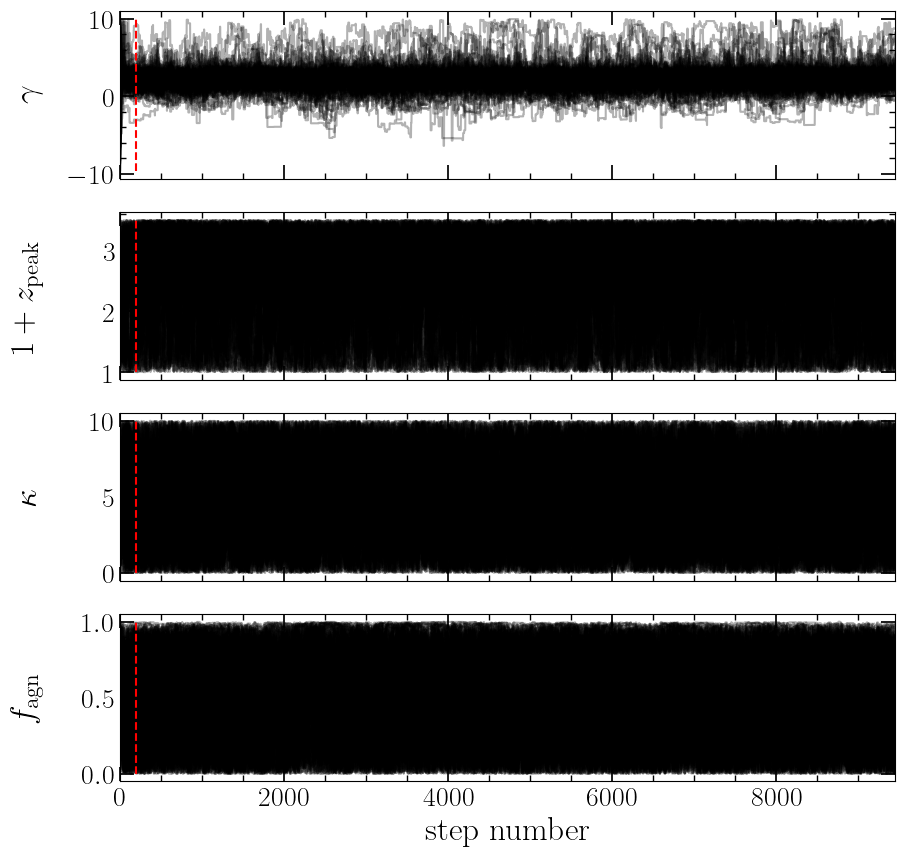

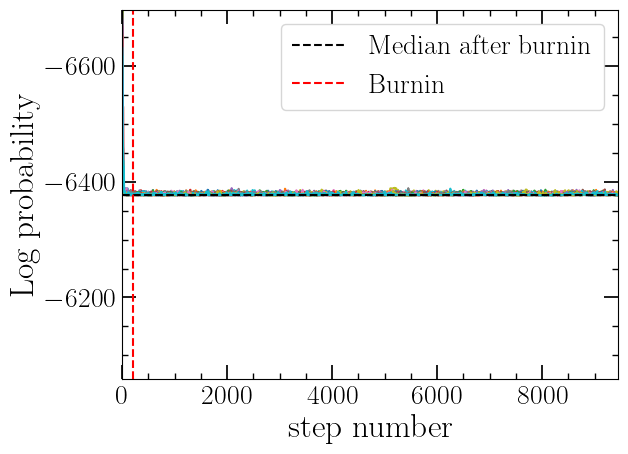

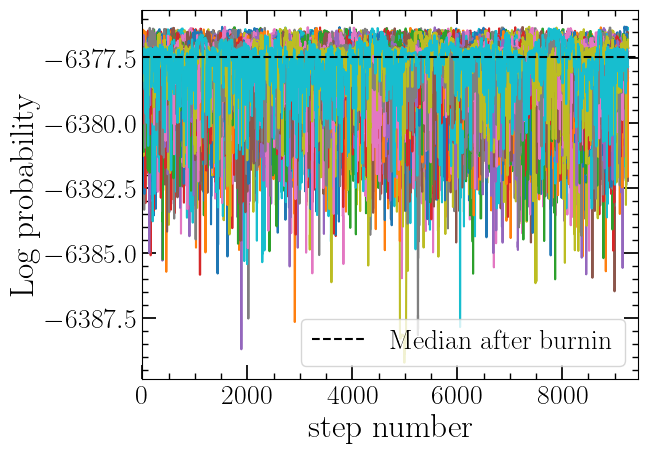

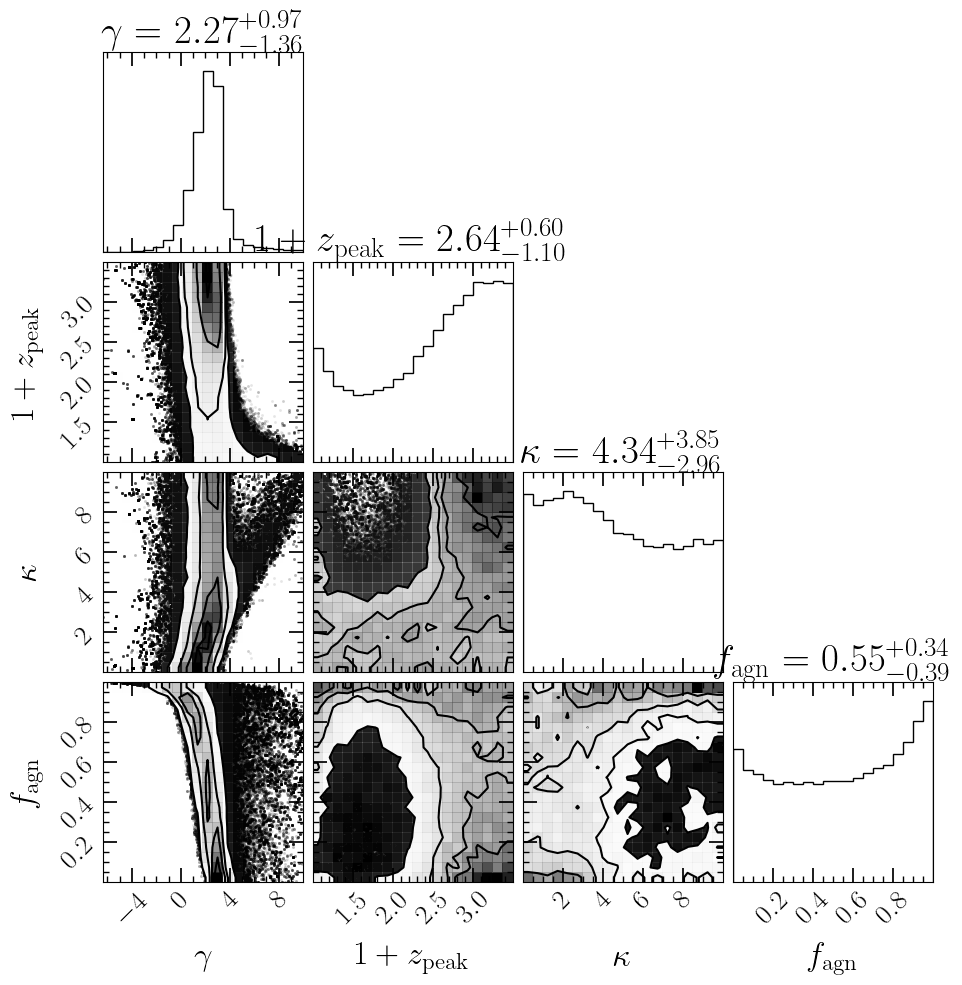

In [21]:
good_samples_uniform, good_logprob_uniform, _ = get_clean_samples_from_backend(filename_uniform, 
																				nwalkers=nwalkers, 
																				ndim=ndim, 
																				burnin=200, 
																				a_low=0.05, 
																				a_high=0.95,
																				quantile=True)


[0.54017372 0.5732899  0.53637351 0.57926167 0.55374593 0.56243214
 0.56514658 0.57871878 0.5597177  0.57166124 0.58794788 0.56460369
 0.59011944 0.53528773 0.55808903 0.55266015 0.54397394 0.57057546
 0.56731813 0.5689468  0.55266015 0.5689468  0.53474484 0.54180239
 0.57546145 0.56568947 0.56026059 0.57654723 0.5689468  0.56786102
 0.56948969 0.57871878 0.5781759  0.5320304  0.5689468  0.56188925
 0.56080347 0.55320304 0.56460369 0.58469055 0.55103149 0.56731813
 0.56460369 0.56840391 0.5597177  0.5732899  0.56297503 0.56948969
 0.60152009 0.54288817 0.58360478 0.57166124 0.56948969 0.56514658
 0.58740499 0.52931596 0.56460369 0.58360478 0.56623236 0.57926167
 0.56948969 0.55700326 0.55646037 0.57491857 0.56786102 0.57166124
 0.56080347 0.57166124 0.56568947 0.56840391 0.57383279 0.51682953
 0.54560261 0.54288817 0.55754615 0.5732899  0.56623236 0.5369164
 0.56623236 0.57437568 0.55863192 0.57003257 0.55754615 0.58740499
 0.57003257 0.56731813 0.56948969 0.55646037 0.55320304 0.60043

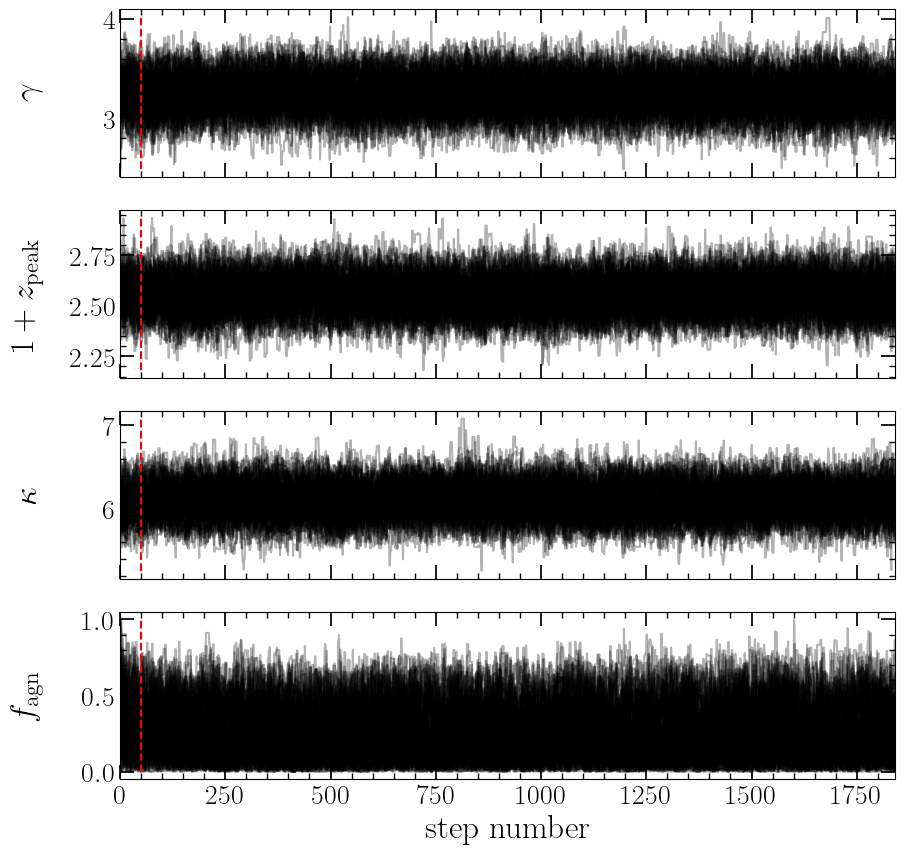

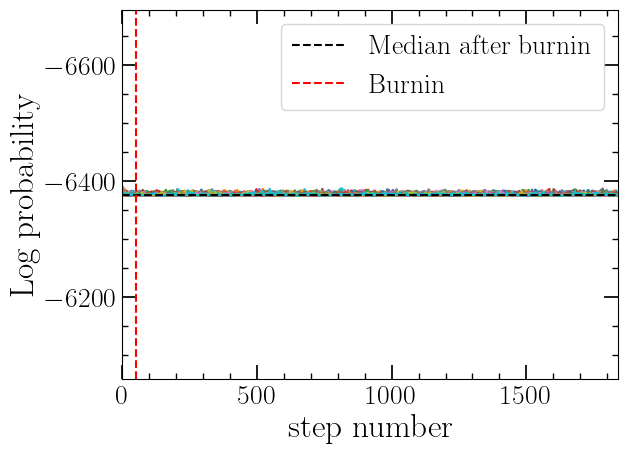

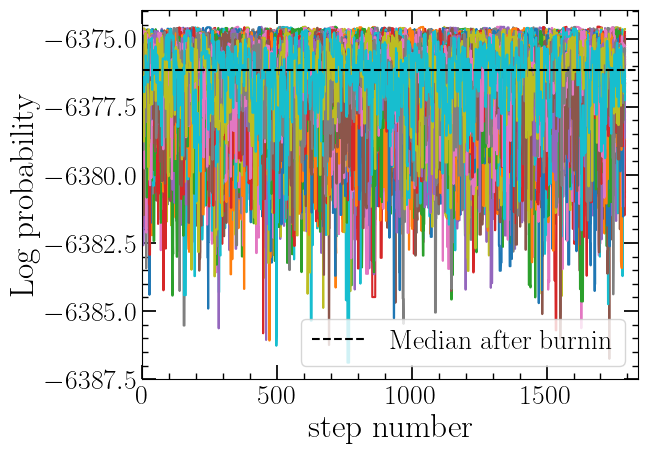

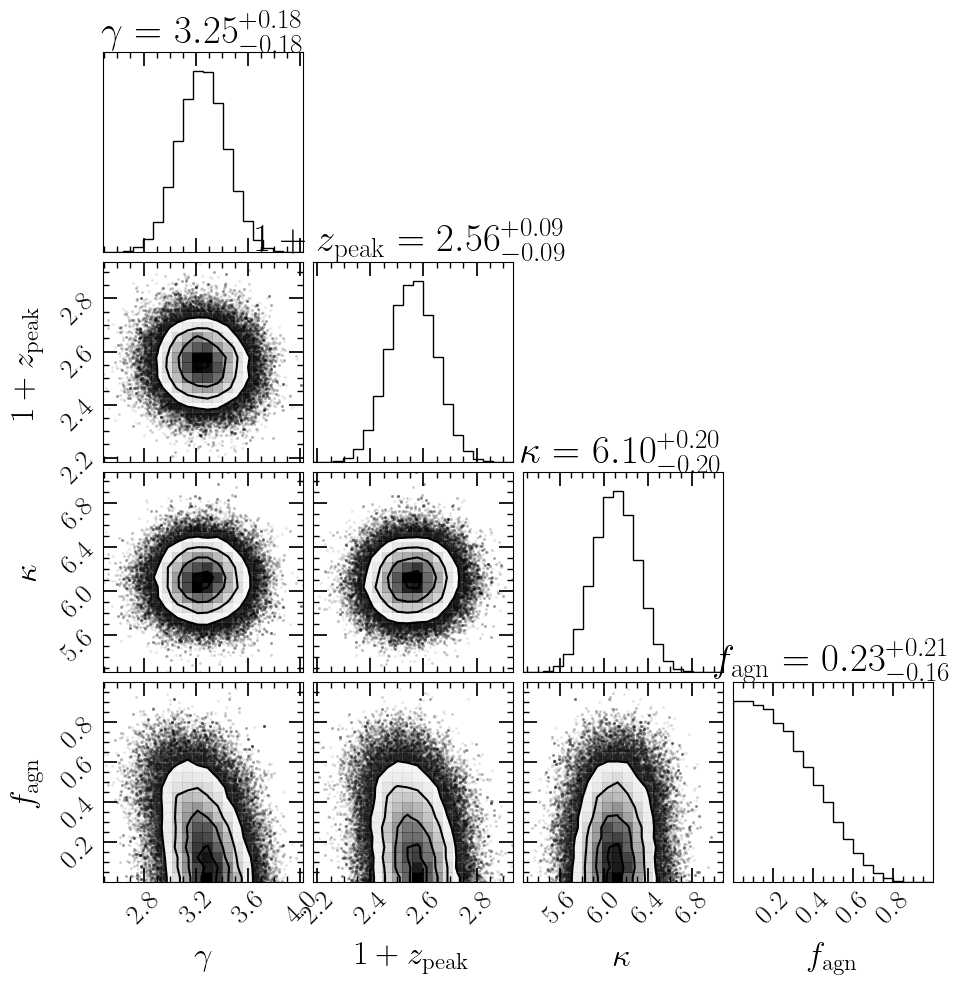

In [22]:
good_samples_gauss, good_logprob_gauss, _ = get_clean_samples_from_backend(filename_gauss, 
																		   nwalkers=nwalkers, 
																		   ndim=ndim, 
																		   burnin=50, 
																		   a_low=0, 
																		   a_high=1)


In [23]:
result = PopulationResult(fname=LVK_HYPERPOSTERIOR_PATH)
df = pd.DataFrame(result.get_hyperparameter_samples(), columns=result.get_metadata("hyperparameters"))

g, z, k = df['gamma'].to_numpy(), df['z_peak'].to_numpy(), df['kappa'].to_numpy()
f = np.random.uniform(0, 1e-6, size=len(g))
samples_LVK = np.array([g, 1 + z, k, f]).T


opening existing popsummary file: /home/lucas/Documents/PhD/gw_data/popsummary_files/gwtc5_updated_madau_dickinson_mmax_mass_TwoPeakBrokenPowerLawSmoothedMassDistribution_redshift_MadauDickinsonRedshift_magnitude_iid_spin_magnitude_gaussian_tilt_iid_spin_orientation_popsummary_result.h5


MAP Uniform prior:
b = 2.85
c = 3.48
d = 9.95
fagn = 0.00
MAP Gaussian prior:
b = 3.30
c = 2.57
d = 6.09
fagn = 0.01


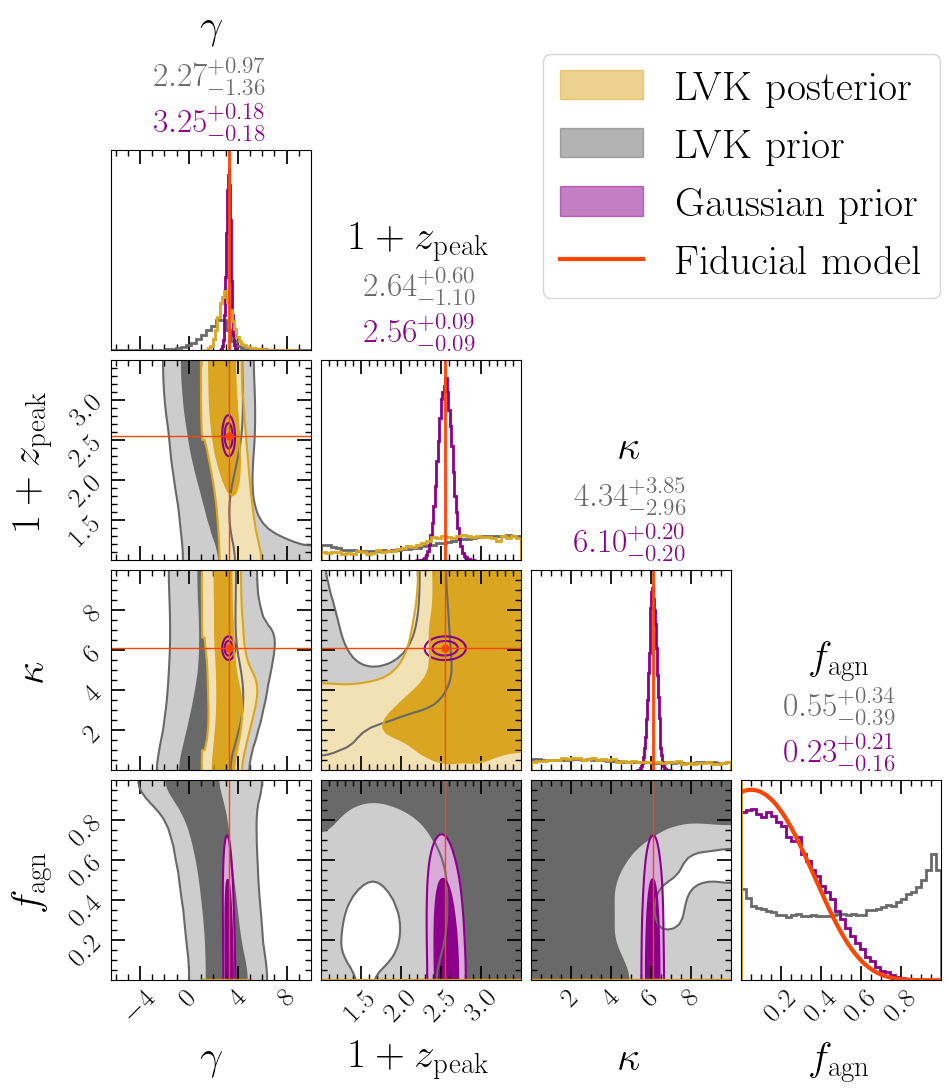

In [24]:
medsize = 24
bigsize = 30
fixedcolors = {'44.5': 'orangered', '45.5': 'navy', '46.5': 'teal'}
labels = [f'{par_names_latex[i]}' for i in range(ndim)]

samples_1 = good_samples_uniform
logprob_1 = good_logprob_uniform

samples_2 = good_samples_gauss
logprob_2 = good_logprob_gauss

# # Optimal values (posterior medians)
# best_1 = np.median(samples_1, axis=0)
# best_2 = np.median(samples_2, axis=0)


best_1 = samples_1[np.argmax(logprob_1), :]
best_2 = samples_2[np.argmax(logprob_2), :]
print(f'MAP Uniform prior:')
for i, name in enumerate(par_names):
	print(f'{name} = {best_1[i]:.2f}')
print(f'MAP Gaussian prior:')
for i, name in enumerate(par_names):
	print(f'{name} = {best_2[i]:.2f}')

uniform_color = "dimgrey"
gauss_color = "darkmagenta"
LVK_color = "goldenrod"

fig = corner.corner(
	samples_1,
	labels=labels,
	label_kwargs={"fontsize": bigsize},
	color=uniform_color,
	bins=40,
	smooth=3.0,
	plot_datapoints=False,
	fill_contours=True,
	plot_density=False,
	levels=(0.68, 0.95),
	alpha=0.5,
	show_titles=False,
	hist_kwargs={"density": True, "linewidth": 2},
)

corner.corner(
	samples_2,
	fig=fig,
	labels=labels,
	label_kwargs={"fontsize": bigsize},
	color=gauss_color,
	bins=40,
	smooth=3.0,
	plot_datapoints=False,
	fill_contours=True,
	plot_density=False,
	levels=(0.68, 0.95),
	alpha=0.5,
	show_titles=False,
	hist_kwargs={"density": True, "linewidth": 2},
)

corner.corner(
	samples_LVK,
	fig=fig,
	labels=labels,
	label_kwargs={"fontsize": bigsize},
	color=LVK_color,
	bins=40,
	smooth=3.0,
	plot_datapoints=False,
	fill_contours=True,
	plot_density=False,
	levels=(0.68, 0.95),
	alpha=0.5,
	show_titles=False,
	hist_kwargs={"density": True, "linewidth": 2},
)

handles = [
	mpatches.Patch(facecolor=LVK_color, edgecolor=LVK_color,
						   alpha=0.5, label="LVK posterior"),
	mpatches.Patch(facecolor=uniform_color, edgecolor=uniform_color,
				   alpha=0.5, label="LVK prior"),
	mpatches.Patch(facecolor=gauss_color, edgecolor=gauss_color,
				   alpha=0.5, label="Gaussian prior"),
	Line2D([0], [0], color=fixedcolors[LTHRESH_STRING], lw=3, label="Fiducial model"),
]

fig.legend(
	handles=handles,
	loc="upper right",
	bbox_to_anchor=(0.98, 1.08),
	frameon=True,
	fontsize=bigsize,
)

# Add best-fit markers
ndim = samples_1.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

best_1 = np.array([3.3, 2.55, 6.1])
for i in range(ndim):
	# 1D histograms
	if i < ndim - 1:
		axes[i, i].axvline(best_1[i], color=fixedcolors[LTHRESH_STRING], lw=2)
	# 2D panels
	for j in range(i):
		axes[i, j].axvline(best_1[j], color=fixedcolors[LTHRESH_STRING], lw=1)
		if (j < ndim - 1) & (i < ndim - 1):
			axes[i, j].axhline(best_1[i], color=fixedcolors[LTHRESH_STRING], lw=1)
			axes[i, j].plot(best_1[j], best_1[i], "o",
							color=fixedcolors[LTHRESH_STRING], ms=5)

axes[3, 3].plot(LOG_LLH_X_AX, fixedpop_post, color=fixedcolors[LTHRESH_STRING], linestyle='solid', linewidth=3)
axes[3, 3].set_ylim(0, 1.05 * np.max(fixedpop_post))

q16_1, q50_1, q84_1 = np.percentile(samples_1, [16, 50, 84], axis=0)
q16_2, q50_2, q84_2 = np.percentile(samples_2, [16, 50, 84], axis=0)

ndim = samples_1.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))


for i in range(ndim):
	ax = axes[i, i]

	# remove corner's default title
	ax.set_title("")

	uniform_txt = (
		rf"${q50_1[i]:.2f}"
		rf"_{{-{q50_1[i]-q16_1[i]:.2f}}}"
		rf"^{{+{q84_1[i]-q50_1[i]:.2f}}}$"
	)

	gauss_txt = (
		rf"${q50_2[i]:.2f}"
		rf"_{{-{q50_2[i]-q16_2[i]:.2f}}}"
		rf"^{{+{q84_2[i]-q50_2[i]:.2f}}}$"
	)

	ax.text(
		0.5, 1.28, uniform_txt,
		transform=ax.transAxes,
		ha="center", va="bottom",
		color=uniform_color,
		fontsize=medsize,
	)

	ax.text(
		0.5, 1.05, gauss_txt,
		transform=ax.transAxes,
		ha="center", va="bottom",
		color=gauss_color,
		fontsize=medsize,
	)

	ax.text(0.5, 1.56, labels[i],
		transform=ax.transAxes,
		ha="center", fontsize=bigsize)

plt.savefig(f'{PLOT_DIR}/corner_{LTHRESH_STRING}.pdf', bbox_inches='tight')
plt.show()


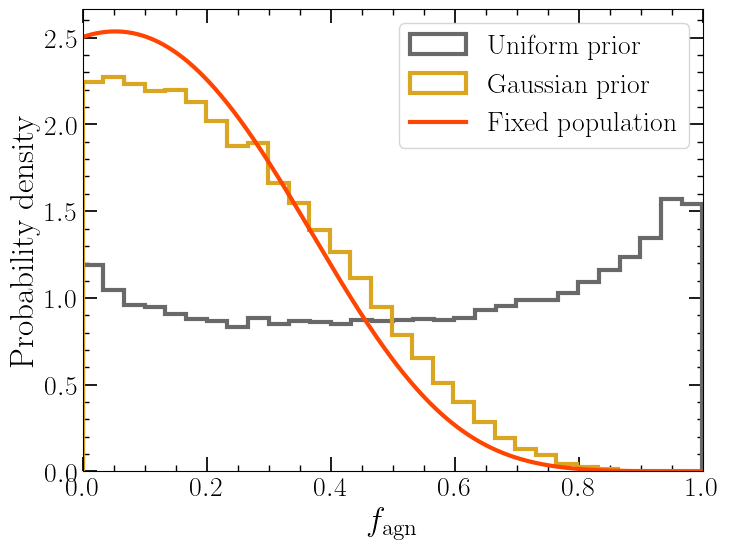

In [25]:
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(samples_1[:,3], histtype='step', bins=30, linewidth=3, color=uniform_color, density=True, label='Uniform prior')
ax.hist(samples_2[:,3], histtype='step', bins=30, linewidth=3, color='goldenrod', density=True, label='Gaussian prior')
ax.plot(LOG_LLH_X_AX, fixedpop_post, color=fixedcolors[LTHRESH_STRING], linestyle='solid', linewidth=3, label='Fixed population')
ax.set_xlim(0, 1)
ax.set_xlabel(r'$f_{\rm agn}$')
ax.set_ylabel('Probability density')
ax.legend()
# plt.savefig(f'{PLOT_DIR}/fagn_priors_{LTHRESH_STRING}.pdf', bbox_inches='tight')
plt.show()


In [26]:
N = int(1e7)
fsamps = sample_from_distribution(CubicSpline(LOG_LLH_X_AX, fixedpop_post), LOG_LLH_X_AX, N)
print(f'Credible interval uniform prior: {hdi(good_samples_uniform[:, 3], cred_mass=0.95)}')
print(f'Credible interval Gaussian prior: {hdi(good_samples_gauss[:, 3], cred_mass=0.95)}')
print(f'Credible interval fixed prior: {hdi(fsamps, cred_mass=0.95)}')


Credible interval uniform prior: (np.float64(0.039543237297709144), np.float64(0.9930263029547436))
Credible interval Gaussian prior: (np.float64(3.516807782613651e-05), np.float64(0.5755520252914359))
Credible interval fixed prior: (np.float64(0.0001), np.float64(0.5233823381313469))
